# Premitives

Youtube - https://www.youtube.com/watch?v=35ykEg3fG4c 

Github - https://github.com/derek-wang-ibm/coding-with-qiskit/blob/main/episode-4-primitives.ipynb

Nature paper - https://www.nature.com/articles/s41586-023-06096-3


## Transverse field Ising model to demo primitives 

In [1]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import YGate, UnitaryGate
import numpy as np

SYGate = UnitaryGate(YGate().power(1/2), label=r'$\sqrt{Y}$')
SYdgGate = UnitaryGate(SYGate.inverse(), label=r'$\sqrt{Y}^\dag$')

def generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, num_cl_bits=0, trotter_barrier=False, layer_barrier=False):
    if num_cl_bits == 0:
        qc = QuantumCircuit(num_qubits)
    else:
        qc = QuantumCircuit(num_qubits, num_cl_bits)

    for trotter_step in range(num_trotter_steps):
        add_1d_tfim_trotter_layer(qc, rx_angle, layer_barrier)
        if trotter_barrier:
            qc.barrier()

    return qc

def add_1d_tfim_trotter_layer(qc, rx_angle, layer_barrier=False):
    # Adding RZZ in the even layers
    for i in range(0, qc.num_qubits - 1, 2):
        qc.sdg([i, i+1])
        qc.append(SYGate, [i+1])
        qc.cx(i, i+1)
        qc.append(SYdgGate, [i+1])

    if layer_barrier:
        qc.barrier()

    # Adding RZZ in the odd layers
    for i in range(1, qc.num_qubits - 1, 2):
        qc.sdg([i, i+1])
        qc.append(SYGate, [i+1])
        qc.cx(i, i+1)
        qc.append(SYdgGate, [i+1])

    if layer_barrier:
        qc.barrier()

    qc.rx(rx_angle, list(range(qc.num_qubits)))
    if layer_barrier:
        qc.barrier()

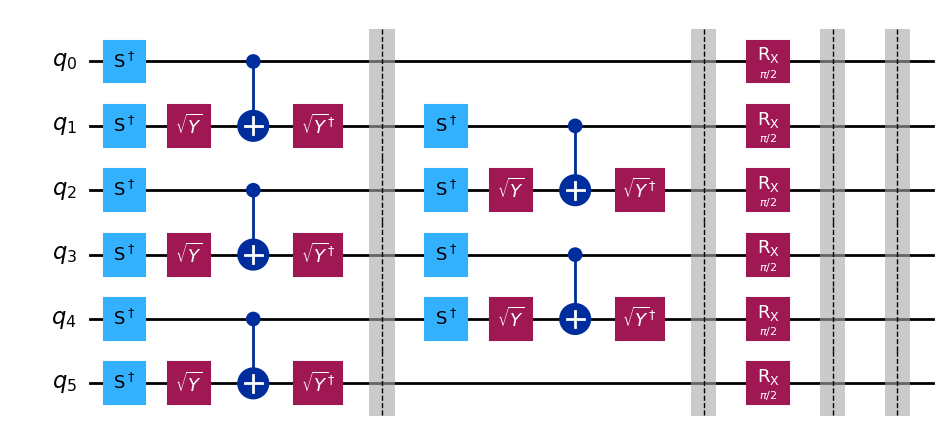

In [2]:
num_qubits = 6
num_trotter_steps = 1   # Number of Trotter steps (layers) use 1, 2
rx_angle = 0.5 * np.pi

qc = generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, trotter_barrier=True, layer_barrier=True)
qc.draw(output='mpl', fold=-1)


## Demo: Sampler
_(copy and paste the info from above and inverse)_

In [3]:
def append_mirrored_1d_tfim_circuit(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barrier=False, layer_barrier=False):
    for trotter_step in range(num_trotter_steps):
        add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barrier)
        if trotter_barrier:
            qc.barrier()
    
def add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barrier=False):
    qc.rx(-rx_angle, list(range(qc.num_qubits)))
    if layer_barrier:
        qc.barrier()

    # Adding RZZ in the odd layers
    for i in range(1, qc.num_qubits - 1, 2):
        qc.append(SYGate, [i+1])
        qc.cx(i, i+1)
        qc.append(SYdgGate, [i+1])
        qc.s([i, i+1])
        
    if layer_barrier:
        qc.barrier()

    for i in range(0, qc.num_qubits - 1, 2):
        qc.append(SYGate, [i+1])
        qc.cx(i, i+1)
        qc.append(SYdgGate, [i+1])
        qc.s([i, i+1])

    if layer_barrier:
        qc.barrier()
            

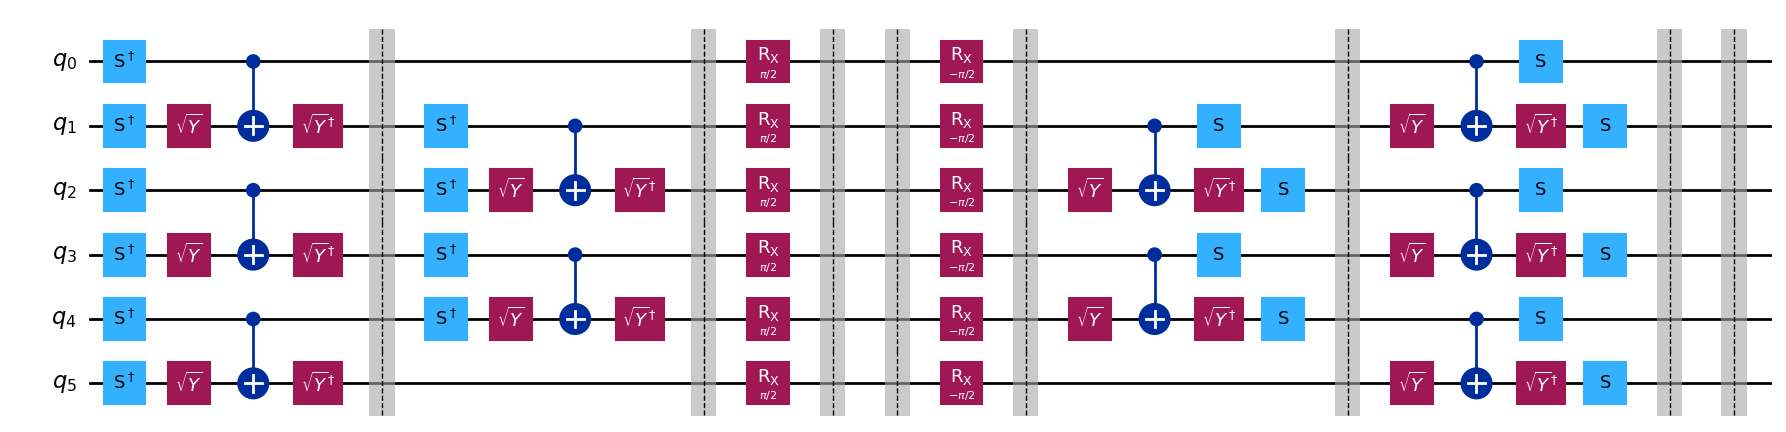

In [4]:
append_mirrored_1d_tfim_circuit(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barrier=True, layer_barrier=True)
qc.draw(output='mpl', fold=-1)

### Step 1: Map the problem to circuit and observables

In [5]:
max_trotter_steps = 10
num_qubits = 100    # 100 or 8
measured_qubits = [49, 50]    # [49, 50] or [4, 5]

qc_list = []
for trotter_step in range(max_trotter_steps):
    qc = generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, num_cl_bits=len(measured_qubits), trotter_barrier=False, layer_barrier=False)
    append_mirrored_1d_tfim_circuit(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barrier=False, layer_barrier=False)
    qc.measure(measured_qubits, [0, 1])
    qc_list.append(qc)

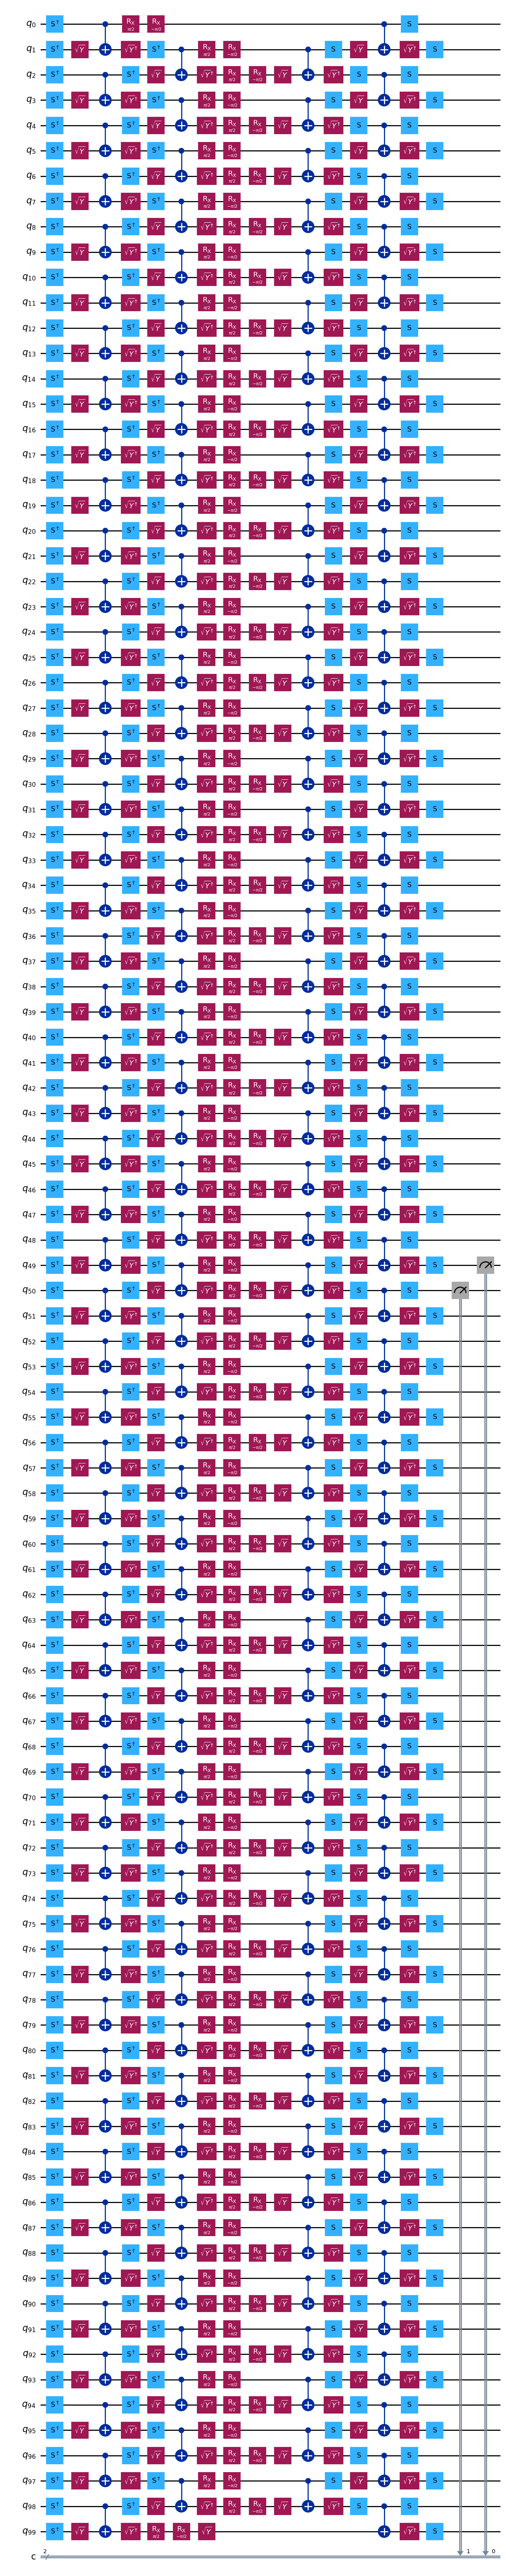

In [6]:
qc_list[0].draw(output='mpl', fold=-1)

### Step 2: Optimize

In [7]:
import os
from dotenv import load_dotenv

# Load the .env file
load_dotenv()

# Retrieve the value using os.getenv
quantum_api_key = os.getenv("QUANTUM_API_KEY")
# print(f"Your API Key is: {quantum_api_key}")

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=quantum_api_key)

backend_name = 'ibm_kingston'     # 156 qubits
# backend_name = 'ibm_fez'          # 156 qubits
# backend_name = 'ibm_marrakesh'    # 156 qubits

backend = service.backend(name=backend_name)
backend.num_qubits

qiskit_runtime_service._discover_account:WARNING:2026-06-07 20:04:49,716: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-06-07 20:04:53,694: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: surnandi. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-07 20:04:53,695: Using instance: surnandi, plan: open


156

In [9]:
from qiskit import transpile

qc_transpiled_list = transpile(qc_list, backend=backend, optimization_level=1)

### Step 3: Execute on hardware

In [10]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(backend)
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = 'XY4'

job = sampler.run(qc_transpiled_list)
job_id = job.job_id()
print(f"Job ID: {job_id}")

Job ID: d8io3c42upec739mfu5g


### Step 4: Post-processing and plotting

In [11]:
job = service.job(job_id)

survival_probability_list = []
for trotter_step in range(max_trotter_steps):
    try:
        data = job.result()[trotter_step].data
        survival_probability_list.append(data.c.get_counts()['0' * len(measured_qubits)] / data.c.num_shots)
    except:
        survival_probability_list.append(0)

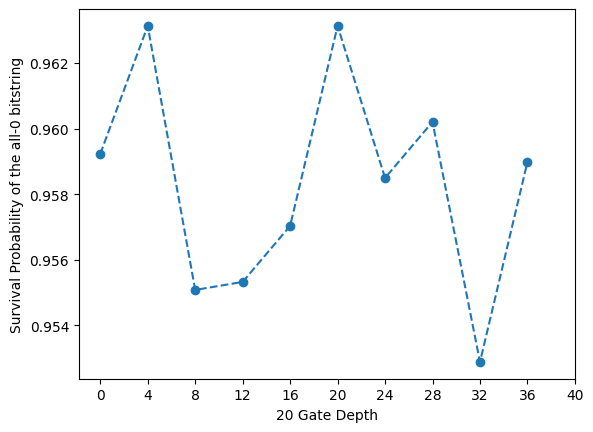

In [12]:
import matplotlib.pyplot as plt

plt.plot(list(range(0, 4 * max_trotter_steps, 4)), survival_probability_list, '--o')
plt.xlabel('20 Gate Depth')
plt.ylabel('Survival Probability of the all-0 bitstring')
plt.xticks(np.arange(0, 44, 4))
plt.show()

## Estimator

### Step 1: Map the problem

In [ ]:
from qiskit.circuit import Parameter
rx_angle = Parameter('rx_angle')
trotter_steps = 2
qc = generate_1d_tfim_circuit(num_qubits, trotter_steps, rx_angle)

from qiskit.quantum_info import SparsePauliOp

middle_index = num_qubits // 2
observable = SparsePauliOp("I" * middle_index + "Z" + "I" * (middle_index - 1))

### Step 2: Optimize the circuit

In [ ]:
qc_transpiled = transpile(qc, backend=backend, optimization_level=1)
observable = observable.apply_layout(qc_transpiled._layout)

### Step 3: Execute on quantum hardware

In [20]:
from qiskit_ibm_runtime import EstimatorV2, EstimatorOptions

min_rx_angle = 0
max_rx_angle = np.pi/2
num_rx_angle = 12
rx_angle_list = np.linspace(min_rx_angle, max_rx_angle, num_rx_angle)

options = EstimatorOptions()
options.resilience_level = 1
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = 'XY4'

estimator = EstimatorV2(backend, options=options)
job = estimator.run([(qc_transpiled, observable, rx_angle_list)])
job_id = job.job_id()
print(f"Job ID: {job_id}")

Job ID: d8iohh42upec739mgdkg


### Step 4: Post processing and plotting

(-0.1, 1.1)

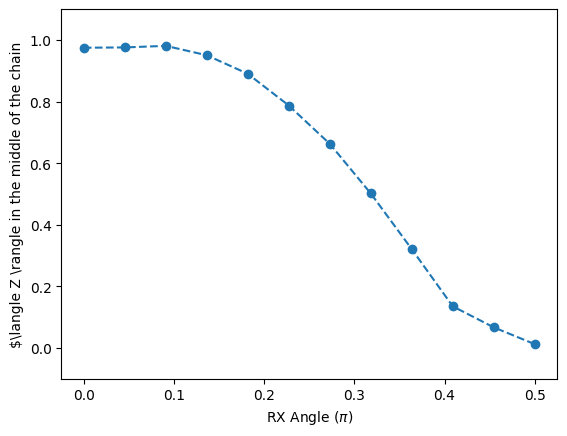

In [22]:
job = service.job(job_id)

exp_val_list = job.result()[0].data.evs

plt.plot(rx_angle_list /np.pi, exp_val_list, '--o')
plt.xlabel(r'RX Angle ($\pi$)')
plt.ylabel(r'$\langle Z \rangle in the middle of the chain')
plt.ylim(-0.1, 1.1)
